ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ ОБРАЗОВАТЕЛЬНОЕ
БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ ВЫСШЕГО ОБРАЗОВАНИЯ
«ФИНАНСОВЫЙ УНИВЕРСИТЕТ ПРИ ПРАВИТЕЛЬСТВЕ
РОССИЙСКОЙ ФЕДЕРАЦИИ»
(ФИНАНСОВЫЙ УНИВЕРСИТЕТ). Кафедра искусственного интеллекта
Факультета информационных технологий и анализа больших данных. Дисциплина: «Машинное обучение в семантическом и сетевом анализе». Направление подготовки: «Прикладная математика и информатика». Профиль: «Прикладное машинное обучение». Форма обучения очная. Учебный 2025/2026 год, 6 семестр.


Выполнил: студент группы ПМ23-6 Аникин Д.А.

Научный руководитель: Казанцев А.М.

In [7]:
import time
import tracemalloc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Импорт библиотек
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS, trustworthiness
from sklearn.random_projection import GaussianRandomProjection
from sklearn.metrics import pairwise_distances
from scipy.stats import pearsonr

import umap
import pacmap
import trimap
import phate


Функция загрузка подвыборки MNIST как прокси для сложных эмбеддингов.

In [ ]:
def load_embeddings(n_samples=3000, random_state=42):
    print("📥 Загрузка данных (MNIST 784D)...")
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X, y = mnist.data, mnist.target.astype(int)
    
    np.random.seed(random_state)
    idx = np.random.choice(len(X), min(n_samples, len(X)), replace=False)
    X, y = X[idx], y[idx]
    
    X = StandardScaler().fit_transform(X)
    print(f"✅ Датасет готов: {X.shape[0]} объектов, {X.shape[1]} признаков")
    return X, y


Функция расчёта Trustworthiness (локальная структура) и корреляции расстояний (глобальная структура).

In [ ]:
def compute_quality_metrics(X_high, X_low, n_ref=1000):
    # Trustworthiness
    trust = trustworthiness(X_high, X_low, n_neighbors=10)
    
    # Глобальная структура: корреляция попарных расстояний (на подвыборке для скорости)
    n = min(n_ref, len(X_high))
    idx = np.random.choice(len(X_high), n, replace=False)
    d_high = pairwise_distances(X_high[idx], metric='euclidean')
    d_low  = pairwise_distances(X_low[idx], metric='euclidean')
    
    triu = np.triu_indices(n, k=1)
    corr, _ = pearsonr(d_high[triu], d_low[triu])
    return trust, 1 - abs(corr)


Функция для модулирования предложенных методов. Автоматический подсчет метрик.

In [ ]:
def run_dr_method(name, func, X, y, **kwargs):
    print(f"\n🔄 {name}...")
    tracemalloc.start()
    t0 = time.perf_counter()
    
    try:
        X_low = func(X, **kwargs)
    except Exception as e:
        print(f"❌ Ошибка: {e}")
        return None
    
    t1 = time.perf_counter()
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    
    elapsed = t1 - t0
    peak_mb = peak / 10**6
    trust, corr = compute_quality_metrics(X, X_low)
    
    print(f"   ⏱ {elapsed:.1f}с | 💾 {peak_mb:.0f}МБ | 🎯 Trust: {trust:.3f} | 🌍 Corr: {corr:.3f}")
    return {"Метод": name, "Время (с)": elapsed, "Память (МБ)": peak_mb, 
            "Trustworthiness": trust, "Global_Corr": corr, "X_low": X_low}


Функция для сравнения методов. Применяет ранее созданную функцию run_dr_method, где параметр func - используемый метод.

In [ ]:
def run_comparison(X, y):
    methods = {
        "Random Projection": lambda X: GaussianRandomProjection(n_components=2, random_state=42).fit_transform(X),
        "PCA": lambda X: PCA(n_components=2, random_state=42).fit_transform(X),
        "MDS": lambda X: MDS(n_components=2, metric=True, random_state=42, n_jobs=1).fit_transform(X),
        "t-SNE": lambda X: TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1).fit_transform(X),
        "UMAP": lambda X: umap.UMAP(n_components=2, random_state=42, n_jobs=-1).fit_transform(X),
        "TriMap": lambda X: trimap.TRIMAP(n_dims=2, n_inliers=10, n_outliers=10, n_random=10).fit_transform(X),
        "PaCMAP": lambda X: pacmap.PaCMAP(n_components=2, n_neighbors=10, random_state=42).fit_transform(X),
        "PHATE": lambda X: phate.PHATE(n_components=2, random_state=42, n_jobs=-1).fit_transform(X),
    }

    results = []
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    axes = axes.flatten()
    
    for i, (name, func) in enumerate(methods.items()):
        res = run_dr_method(name, func, X, y)
        if res is None:
            axes[i].text(0.5, 0.5, f"❌ {name}\nНе удалось выполнить", 
                         transform=axes[i].transAxes, ha='center', va='center', fontsize=12, color='red')
            continue
            
        results.append(res)
        ax = axes[i]
        sns.scatterplot(x=res["X_low"][:,0], y=res["X_low"][:,1], hue=y, 
                        palette="tab10", legend=False, ax=ax, s=15, alpha=0.75)
        ax.set_title(f"{name}\n⏱ {res['Время (с)']:.1f}с | 💾 {res['Память (МБ)']:.0f}МБ\n🎯 {res['Trustworthiness']:.2f} | 🌍 {res['Global_Corr']:.2f}", 
                     fontsize=10, pad=10)
        ax.set_xticks([]); ax.set_yticks([])
        ax.grid(True, alpha=0.3)
        
    plt.suptitle("Сравнительная визуализация методов снижения размерности (MNIST 784D)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    df = pd.DataFrame(results)[["Метод", "Время (с)", "Память (МБ)", "Trustworthiness", "Global_Corr"]]
    return df


Запуск функции run_comparison

📥 Загрузка данных (MNIST 784D)...
✅ Датасет готов: 3000 объектов, 784 признаков

🔄 Random Projection...
   ⏱ 0.0с | 💾 0МБ | 🎯 Trust: 0.580 | 🌍 Corr: 0.533

🔄 PCA...
   ⏱ 0.1с | 💾 20МБ | 🎯 Trust: 0.669 | 🌍 Corr: 0.606

🔄 MDS...
   ⏱ 678.4с | 💾 540МБ | 🎯 Trust: 0.681 | 🌍 Corr: 0.191

🔄 t-SNE...
   ⏱ 25.8с | 💾 30МБ | 🎯 Trust: 0.934 | 🌍 Corr: 0.758

🔄 UMAP...
   ⏱ 23.8с | 💾 91МБ | 🎯 Trust: 0.901 | 🌍 Corr: 0.830

🔄 TriMap...


   ⏱ 9.0с | 💾 24МБ | 🎯 Trust: 0.887 | 🌍 Corr: 0.948

🔄 PaCMAP...
   ⏱ 1.4с | 💾 28МБ | 🎯 Trust: 0.886 | 🌍 Corr: 0.981

🔄 PHATE...
Calculating PHATE...
  Running PHATE on 3000 observations and 784 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 0.29 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.19 seconds.
    Calculating affinities...
    Calculated affinities in 0.51 seconds.
  Calculated graph and diffusion operator in 1.00 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.78 seconds.
    Calculating KMeans...
    Calculated KMeans in 3.09 seconds.
  Calculated landmark operator in 3.87 seconds.
  Calculating optimal t...
    Automatically selected t = 23
  Calculated optimal t in 1.51 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.66 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 2.40 seconds.
Calculated PHATE in 

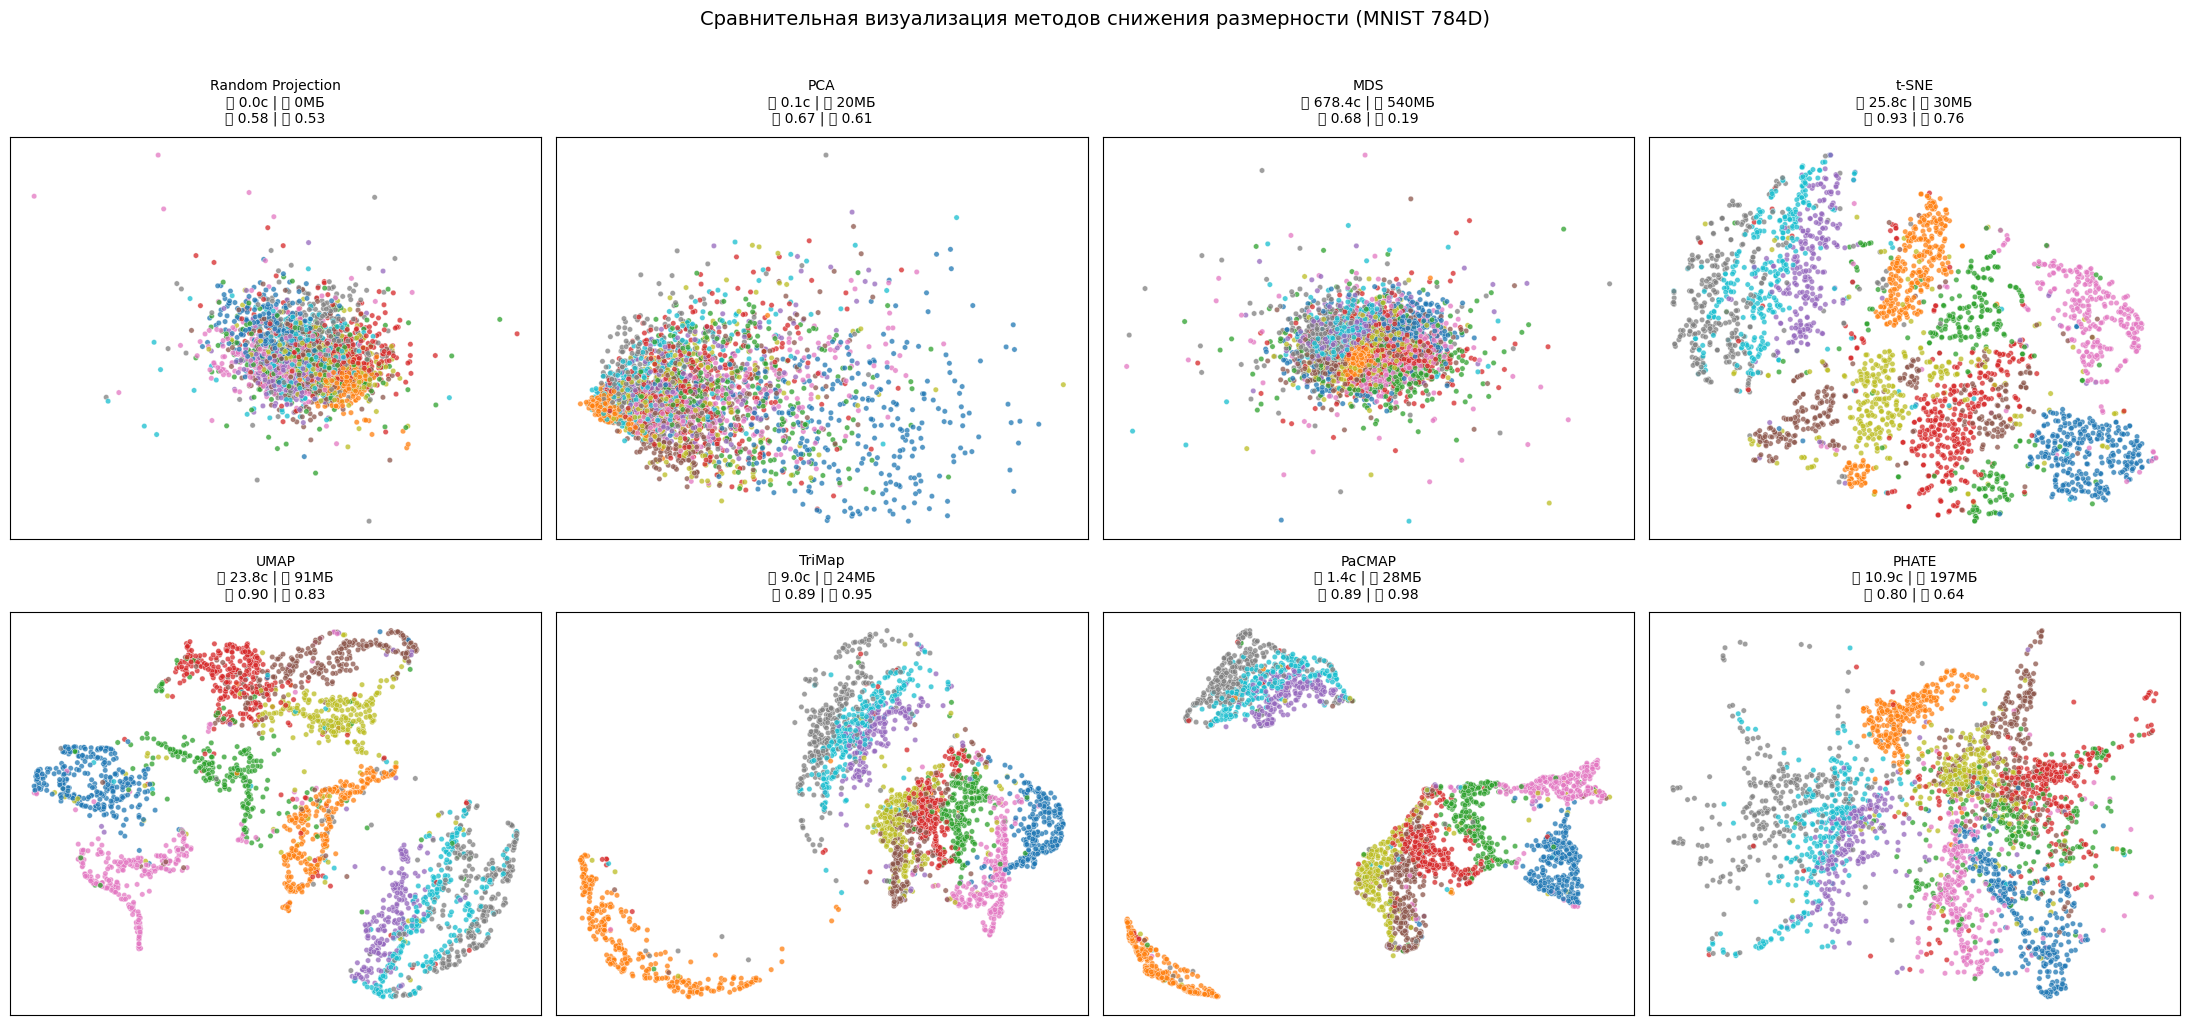


📊 ИТОГОВАЯ ТАБЛИЦА ДЛЯ ПОЯСНИТЕЛЬНОЙ ЗАПИСКИ:


,Метод,Время (с),Память (МБ),Trustworthiness,Global_Corr
0,Random Projection,0.008363,0.063909,0.580070,0.532888
1,PCA,0.134923,19.793752,0.669461,0.606424
2,MDS,678.367887,540.182366,0.680533,0.190765
3,t-SNE,25.782466,29.658022,0.933526,0.758125
4,UMAP,23.776978,91.196696,0.901117,0.829690
5,TriMap,9.047370,24.064248,0.886648,0.948468
6,PaCMAP,1.445542,28.226200,0.885798,0.981476
7,PHATE,10.947207,196.557660,0.796405,0.643520



💾 Результаты сохранены в dr_comparison_results.csv


In [ ]:
if __name__ == "__main__":
    X, y = load_embeddings(n_samples=3000) 
    comparison_df = run_comparison(X, y)
    
    print("\n📊 ИТОГОВАЯ ТАБЛИЦА ДЛЯ ПОЯСНИТЕЛЬНОЙ ЗАПИСКИ:")
    display(comparison_df.style.set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f5f5f5'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ]))
    
    # Экспорт для отчёта
    comparison_df.to_csv("dr_comparison_results.csv", index=False)
    print("\n💾 Результаты сохранены в dr_comparison_results.csv")